# NB03 — Phylogenetic Distribution and Bias Testing

Fisher's exact + BH-FDR phylum enrichment for each category. Pagel's λ using R subprocess. Dual-specialist scatter.

In [1]:
import sys, os, re, warnings, requests, json, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import fisher_exact, norm
from statsmodels.stats.multitest import fdrcorrection
warnings.filterwarnings("ignore")

try:
    spark
except NameError:
    sys.path.append('/opt/conda/lib/python3.13/site-packages')
    from berdl_notebook_utils.setup_spark_session import get_spark_session
    spark = get_spark_session()
from pyspark.sql import functions as F

NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR  = NOTEBOOK_DIR.parent
DATA_DIR     = PROJECT_DIR / "data"
FIG_DIR      = PROJECT_DIR / "figures"
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

def is_valid_parquet(p):
    if not p.exists() or p.stat().st_size < 512:
        return False
    try:
        import pyarrow.parquet as pq; pq.read_schema(str(p)); return True
    except Exception:
        return False

def wilson_ci(n, N, alpha=0.05):
    if N == 0: return np.nan, np.nan
    p = n / N; z = norm.ppf(1 - alpha/2)
    denom = 1 + z**2/N
    centre = (p + z**2/(2*N)) / denom
    half = z * np.sqrt(p*(1-p)/N + z**2/(4*N**2)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)

def odds_ratio_ci(a, b, c, d, alpha=0.05):
    # Woolf logit OR with 95% CI
    a,b,c,d = a+0.5, b+0.5, c+0.5, d+0.5
    log_or = np.log(a*d/(b*c))
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    z = norm.ppf(1 - alpha/2)
    return np.exp(log_or), np.exp(log_or - z*se), np.exp(log_or + z*se)

print("Setup complete.")

Setup complete.


## Section 1 — Load Data

In [2]:
genome_counts = pd.read_parquet(DATA_DIR / "genome_metal_counts.parquet")
print(f"Loaded {len(genome_counts)} genomes")
print(genome_counts.head())

Loaded 27690 genomes
            genome_id                          species          phylum  \
0  GB_GCA_023387895.1         s__Gordonia alkanivorans  Actinomycetota   
1  GB_GCA_900444685.1         s__Achromobacter spanius  Pseudomonadota   
2  RS_GCF_001541345.2           s__Allorhizobium vitis  Pseudomonadota   
3  GB_GCA_018714445.1  s__Fimadaptatus faecigallinarum     Bacillota_A   
4  GB_GCA_020441065.1          s__JACKOY01 sp024233935   Spirochaetota   

                 class          order_rank              family          genus  \
0        Actinomycetia     Mycobacteriales    Mycobacteriaceae       Gordonia   
1  Gammaproteobacteria     Burkholderiales  Burkholderiaceae_C  Achromobacter   
2  Alphaproteobacteria         Rhizobiales        Rhizobiaceae  Allorhizobium   
3           Clostridia  Christensenellales              CAG-74   Fimadaptatus   
4          Leptospirae       Leptospirales     Leptonemataceae       JACKOY01   

   n_defense  n_metabolism  n_homeostasis  n_me

## Section 2 — Phylum Enrichment

Fisher's exact test for enrichment of each category in each phylum. Apply BH-FDR correction.

In [3]:
MAJOR_PHYLA = ['Actinomycetota', 'Pseudomonadota', 'Bacillota', 'Chloroflexota', 'Bacteroidota', 'Cyanobacteriota']
categories = ['defense', 'metabolism', 'homeostasis']

enrichment_rows = []
pvalues = []

for phylum in MAJOR_PHYLA:
    phylum_data = genome_counts[genome_counts['phylum'] == phylum]
    rest_data = genome_counts[genome_counts['phylum'] != phylum]
    
    for category in categories:
        col = f"n_{category}"
        
        phylum_has = (phylum_data[col] > 0).sum()
        phylum_not = (phylum_data[col] == 0).sum()
        rest_has = (rest_data[col] > 0).sum()
        rest_not = (rest_data[col] == 0).sum()
        
        oddsratio, pval = fisher_exact([[phylum_has, phylum_not], [rest_has, rest_not]], alternative='two-sided')
        or_est, or_ci_low, or_ci_high = odds_ratio_ci(phylum_has, phylum_not, rest_has, rest_not)
        
        enrichment_rows.append({
            'phylum': phylum,
            'category': category,
            'phylum_has': phylum_has,
            'phylum_not': phylum_not,
            'rest_has': rest_has,
            'rest_not': rest_not,
            'odds_ratio': or_est,
            'or_ci_low': or_ci_low,
            'or_ci_high': or_ci_high,
            'p_value': pval
        })
        pvalues.append(pval)

enrichment_df = pd.DataFrame(enrichment_rows)

# BH-FDR correction (18 tests: 6 phyla × 3 categories)
reject_bh, q_values_bh = fdrcorrection(enrichment_df['p_value'].values, alpha=0.05)
enrichment_df['q_value_bh'] = q_values_bh
enrichment_df['significant_bh'] = reject_bh

# Bonferroni correction — more conservative; tests share a common comparator group
from statsmodels.stats.multitest import multipletests
reject_bon, q_values_bon, _, _ = multipletests(enrichment_df['p_value'].values, alpha=0.05, method='bonferroni')
enrichment_df['q_value_bonferroni'] = q_values_bon
enrichment_df['significant_bonferroni'] = reject_bon

enrichment_df.to_csv(DATA_DIR / "phylum_enrichment.csv", index=False)

print(f"Total tests: {len(enrichment_df)} (6 phyla × 3 categories)")
print("\nSignificant by BH-FDR (q < 0.05):")
sig_bh = enrichment_df[enrichment_df['significant_bh']]
print(sig_bh[['phylum', 'category', 'odds_ratio', 'or_ci_low', 'or_ci_high', 'q_value_bh', 'q_value_bonferroni']].to_string(index=False))

print("\nSignificant by Bonferroni but NOT BH-FDR (downgraded):")
bh_sig_set = set(sig_bh[['phylum','category']].apply(tuple, axis=1))
sig_bon_only = enrichment_df[enrichment_df['significant_bonferroni'] & ~enrichment_df['significant_bh']]
if len(sig_bon_only) == 0:
    print("  (none — BH-FDR is more liberal, so all Bonferroni-significant tests are also BH-significant)")
else:
    print(sig_bon_only[['phylum', 'category', 'odds_ratio', 'q_value_bonferroni']].to_string(index=False))


Total tests: 18 (6 phyla × 3 categories)

Significant by BH-FDR (q < 0.05):
         phylum    category  odds_ratio  or_ci_low  or_ci_high    q_value_bh  q_value_bonferroni
 Actinomycetota     defense    6.582090   3.191952   13.572857  2.133433e-12        2.133433e-11
 Actinomycetota  metabolism    1.609514   1.490584    1.737934  1.530539e-34        1.224431e-33
 Actinomycetota homeostasis    1.544468   1.345258    1.773178  1.308779e-10        1.570535e-09
 Pseudomonadota     defense   31.653404  12.491729   80.208110  1.632969e-45        1.143078e-44
 Pseudomonadota  metabolism    2.921576   2.757640    3.095259 4.516419e-311       4.516419e-311
 Pseudomonadota homeostasis   11.006814   9.076712   13.347339 2.248645e-269       4.497289e-269
      Bacillota     defense    0.653269   0.474988    0.898467  1.754347e-02        2.806954e-01
      Bacillota  metabolism    0.442271   0.403501    0.484766  1.222238e-70        6.111191e-70
      Bacillota homeostasis    1.471241   1.249479 

## Section 3 — Forest Plot

Horizontal bar chart showing log2(OR) ± log2(CI) for each phylum per category.

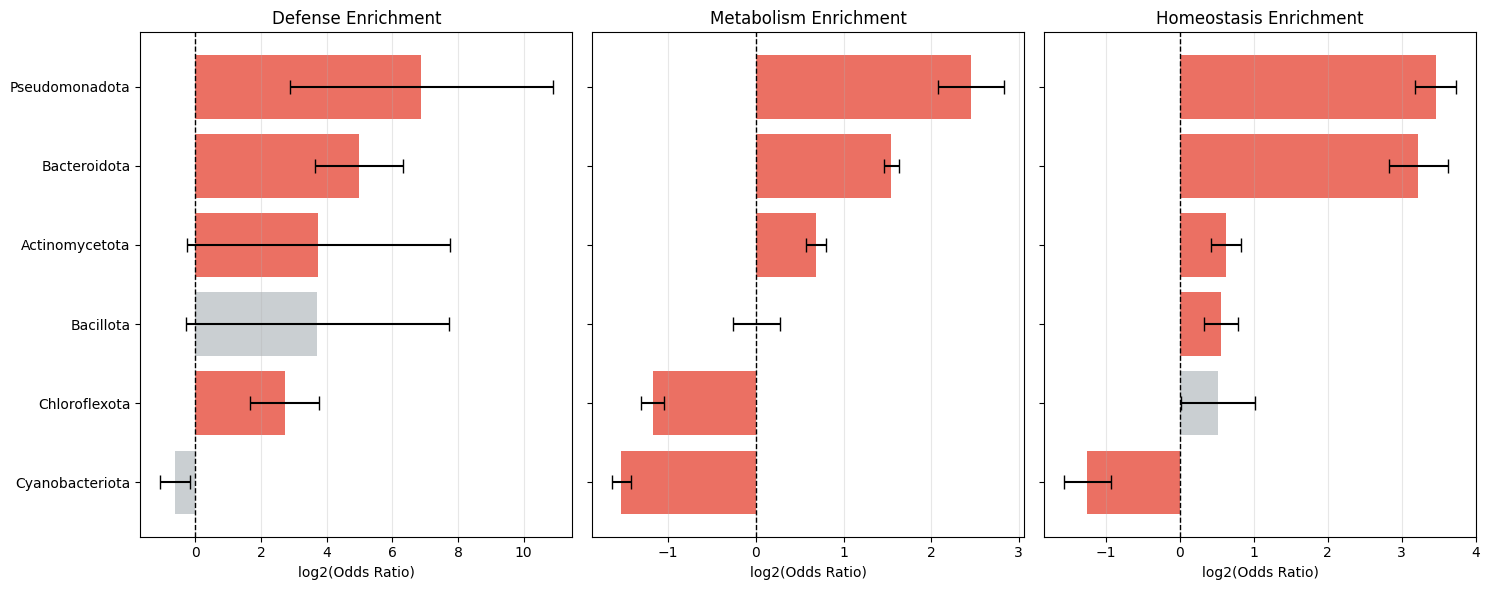

Figure saved: nb03_forest_phylum_enrichment.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for i, category in enumerate(['defense', 'metabolism', 'homeostasis']):
    cat_data = enrichment_df[enrichment_df['category'] == category].copy()
    cat_data = cat_data.sort_values('odds_ratio')
    
    ax = axes[i]
    
    y_pos = np.arange(len(cat_data))
    log2_or = np.log2(cat_data['odds_ratio'].values)
    log2_ci_low = np.log2(cat_data['or_ci_low'].values)
    log2_ci_high = np.log2(cat_data['or_ci_high'].values)
    
    errors = np.array([log2_or - log2_ci_low, log2_ci_high - log2_or])
    
    if 'significant_bonferroni' in cat_data.columns:
        colors = ['#e74c3c' if sig else '#bdc3c7' for sig in cat_data['significant_bonferroni'].values]
    else:
        colors = ['#e74c3c' if q < 0.05 else '#bdc3c7' for q in cat_data['q_value_bh'].values]
    
    ax.barh(y_pos, log2_or, xerr=errors, color=colors, capsize=5, alpha=0.8)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cat_data['phylum'].values)
    ax.set_xlabel('log2(Odds Ratio)')
    ax.set_title(f"{category.capitalize()} Enrichment")
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "nb03_forest_phylum_enrichment.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: nb03_forest_phylum_enrichment.png")

## Section 4 — Pagel's λ

Export species trait matrix and run phylogenetic signal test in R.

In [5]:
from Bio import Phylo

bac_tree_path = DATA_DIR / 'pruned_bac_species_tree.nwk'
arc_tree_path = DATA_DIR / 'pruned_arc_species_tree.nwk'

if not bac_tree_path.exists():
    GTDB_DIR = Path("/home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data")
    bac_all = Phylo.read(GTDB_DIR / 'gtdb_bac120_r214.tree', 'newick')
    arc_all = Phylo.read(GTDB_DIR / 'gtdb_ar53_r214.tree', 'newick')
    bac_tax = pd.read_csv(GTDB_DIR / 'gtdb_bac120_taxonomy_parsed.csv')
    arc_tax = pd.read_csv(GTDB_DIR / 'gtdb_ar53_taxonomy_parsed.csv')
    all_tax = pd.concat([bac_tax, arc_tax], ignore_index=True)
    acc_to_sp = dict(zip(all_tax['accession'], all_tax['gtdb_species']))
    for tree, path in [(bac_all, bac_tree_path), (arc_all, arc_tree_path)]:
        keep = {t.name for t in tree.get_terminals()} & set(acc_to_sp)
        for t in tree.get_terminals():
            if t.name not in keep:
                tree.prune(t)
        for t in tree.get_terminals():
            t.name = acc_to_sp.get(t.name, t.name)
        Phylo.write(tree, path, 'newick')
        print(f"Pruned tree: {len(tree.get_terminals())} tips → {path.name}")

bac_tips = {t.name for t in Phylo.read(bac_tree_path, 'newick').get_terminals()}
arc_tips = {t.name for t in Phylo.read(arc_tree_path, 'newick').get_terminals()}
all_tips  = bac_tips | arc_tips

gc = genome_counts.copy()
gc['sp'] = gc['species'].str.removeprefix('s__')

# Continuous gene counts — used for Pagel's λ (λ requires a continuous trait).
# genome_counts has one row per species so .first() == the value for that species.
n_cols = gc.groupby('sp')[['n_defense', 'n_metabolism', 'n_homeostasis']].first()

# Binary columns retained for prevalence reporting only; NOT passed to write_trait_file.
binary_cols = (n_cols > 0).astype(int)
binary_cols.columns = ['has_defense', 'has_metabolism', 'has_homeostasis']

tax_cols = gc.groupby('sp')[['phylum', 'class', 'order_rank', 'family', 'genus']].first()
tax_cols = tax_cols.rename(columns={'class': 'klass', 'order_rank': 'order'})

# matched contains both continuous n_* (for λ) and binary has_* (for prevalence reporting)
species_traits = pd.concat([n_cols, binary_cols, tax_cols], axis=1).reset_index().rename(columns={'sp': 'species'})
species_traits['domain'] = np.where(
    species_traits['species'].isin(bac_tips), 'Bacteria',
    np.where(species_traits['species'].isin(arc_tips), 'Archaea', None)
)
matched = species_traits.dropna(subset=['domain']).copy()
print(f"Species in tree: {len(matched):,}  "
      f"(Bacteria: {(matched['domain']=='Bacteria').sum():,}, "
      f"Archaea: {(matched['domain']=='Archaea').sum():,})")
print(f"Defense prevalence: {matched['has_defense'].mean():.1%}  "
      f"Metabolism: {matched['has_metabolism'].mean():.1%}  "
      f"Homeostasis: {matched['has_homeostasis'].mean():.1%}")
print(f"Mean n_defense: {matched['n_defense'].mean():.2f}  "
      f"n_metabolism: {matched['n_metabolism'].mean():.2f}  "
      f"n_homeostasis: {matched['n_homeostasis'].mean():.2f}")


Species in tree: 27,690  (Bacteria: 26,525, Archaea: 1,165)
Defense prevalence: 98.6%  Metabolism: 54.0%  Homeostasis: 89.3%
Mean n_defense: 23.09  n_metabolism: 2.79  n_homeostasis: 5.01


In [6]:
LAMBDA_CSV  = DATA_DIR / 'pagel_lambda_summary.csv'
RSCRIPT     = Path('/home/hmacgregor/r_env/bin/Rscript')
LEVEL_COLS  = ['phylum', 'klass', 'order', 'family', 'genus']
LEVEL_NAMES = {'phylum': 'phylum', 'klass': 'class', 'order': 'order',
               'family': 'family', 'genus': 'genus'}
# phylosig() is O(n^2); skip levels with too many taxa to avoid timeout.
# Bacteria genus (7858) and family (2231) exceed this; Archaea all levels are fine.
MAX_TAXA = 1000

def write_trait_file(df, level_col, tree_tips, path):
    # Aggregate continuous gene counts (mean across species in each taxon).
    # Pagel's λ is only valid for continuous traits; binary presence/absence is inappropriate.
    agg = (
        df[df['species'].isin(tree_tips) & df[level_col].notna()]
        .groupby(level_col, as_index=False)
        .agg(accession=('species', 'first'),
             n_defense    =('n_defense',    'mean'),
             n_metabolism =('n_metabolism', 'mean'),
             n_homeostasis=('n_homeostasis','mean'))
        .rename(columns={level_col: 'taxon'})
    )
    agg.to_csv(path, index=False)
    return len(agg)

def run_pagel_r(tree_path, trait_csv, level, domain, timeout=600):
    r_code = f"""
suppressPackageStartupMessages({{ library(ape); library(phytools) }})
tree   <- read.tree("{tree_path}")
# BioPython writes species names with spaces wrapped in apostrophes; ape preserves them.
# Strip any apostrophes so tip labels match the accession column in the trait CSV.
tree$tip.label <- gsub("'", "", tree$tip.label)
traits <- read.csv("{trait_csv}")
common <- intersect(tree$tip.label, traits$accession)
if (length(common) < 3) {{ q(save="no") }}
tree   <- keep.tip(tree, common)
idx    <- match(tree$tip.label, traits$accession)
tree$tip.label <- traits$taxon[idx]
rownames(traits) <- traits$taxon
if (!is.ultrametric(tree)) tree <- force.ultrametric(tree, method="extend")
for (tc in c("n_defense","n_metabolism","n_homeostasis")) {{
    tv <- setNames(as.numeric(traits[[tc]]), rownames(traits))
    if (var(tv, na.rm=TRUE) < 1e-10) next
    sig <- tryCatch(phylosig(tree, tv, method="lambda", test=TRUE), error=function(e) NULL)
    if (is.null(sig)) next
    cat(paste0("{domain},{level},", tc, ",", round(sig$lambda,4), ",", format(sig$P, scientific=TRUE), "\\n"))
}}
"""
    res = subprocess.run([str(RSCRIPT), '-'], input=r_code, capture_output=True,
                         text=True, timeout=timeout)
    if res.returncode != 0:
        print(f"  R error [{domain}/{level}]: {res.stderr[:200]}")
    return res.stdout

if LAMBDA_CSV.exists():
    df_lambda = pd.read_csv(LAMBDA_CSV)
    print(f"Loaded cached Pagel's λ results ({len(df_lambda)} rows)")
    print("Note: if trait files were updated, delete pagel_lambda_summary.csv to recompute.")
else:
    DOMAINS = {'Bacteria': (bac_tree_path, bac_tips), 'Archaea': (arc_tree_path, arc_tips)}
    results  = []
    for domain, (tree_path, tips) in DOMAINS.items():
        dom_df = matched[matched['domain'] == domain].copy()
        for col in LEVEL_COLS:
            label = LEVEL_NAMES[col]
            trait_file = DATA_DIR / f'traits_{domain}_{col}.csv'
            n = write_trait_file(dom_df, col, tips, trait_file)
            if n > MAX_TAXA:
                print(f"  {domain}/{label}: {n} taxa — skipped (>{MAX_TAXA}, too slow for phylosig)")
                continue
            print(f"  {domain}/{label}: {n} taxa", end=' ... ', flush=True)
            stdout = run_pagel_r(str(tree_path), str(trait_file), label, domain)
            for line in stdout.splitlines():
                parts = line.strip().split(',')
                if len(parts) == 5:
                    results.append({'domain': parts[0], 'level': parts[1], 'trait': parts[2],
                                    'lambda': float(parts[3]), 'p_value': float(parts[4])})
                    print(f"λ={parts[3]}", end='  ', flush=True)
            print()
    df_lambda = pd.DataFrame(results)
    df_lambda.to_csv(LAMBDA_CSV, index=False)
    print(f"\nSaved {len(df_lambda)} results → {LAMBDA_CSV.name}")

  Bacteria/phylum: 125 taxa ... 

λ=3.0341  

λ=1e-04  

λ=1.9565  


  Bacteria/class: 311 taxa ... 

...


  Archaea/genus: 561 taxa ... 

λ=1.1376  

λ=1.0988  

λ=1.0345  



Saved 24 results → pagel_lambda_summary.csv


=== Significant Pagel's λ (p < 0.05) — continuous gene counts ===
  domain  level         trait  lambda       p_value
 Archaea  class     n_defense  1.4232  1.756243e-02
 Archaea  class  n_metabolism  1.4623  2.777477e-02
 Archaea  class n_homeostasis  1.3452  3.262425e-02
 Archaea  order     n_defense  1.7252  1.220605e-09
 Archaea  order  n_metabolism  1.7898  1.076820e-08
 Archaea  order n_homeostasis  1.2177  7.887108e-07
 Archaea family     n_defense  1.2441  2.769742e-24
 Archaea family  n_metabolism  1.2559  1.843403e-25
 Archaea family n_homeostasis  0.8309  7.013758e-22
 Archaea  genus     n_defense  1.1376 1.216162e-103
 Archaea  genus  n_metabolism  1.0988  1.086154e-98
 Archaea  genus n_homeostasis  1.0345 4.276983e-115
Bacteria phylum     n_defense  3.0341  2.075546e-06
Bacteria phylum n_homeostasis  1.9565  2.501718e-03
Bacteria  class     n_defense  1.9458  9.681715e-21
Bacteria  class  n_metabolism  1.8261  3.081405e-16
Bacteria  class n_homeostasis  1.6837  2.052477e-1

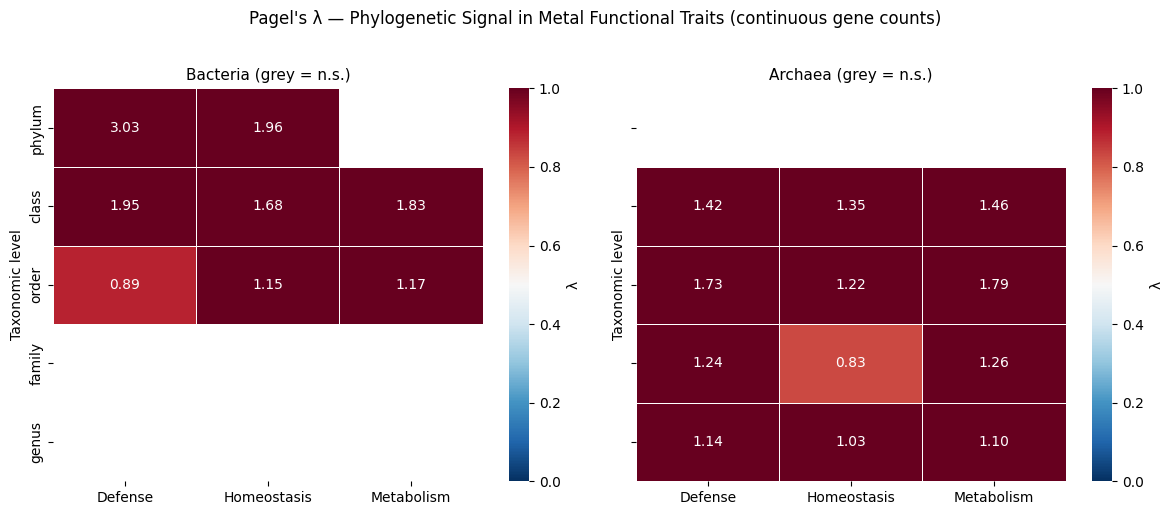

In [7]:
LEVEL_ORDER = ['phylum', 'class', 'order', 'family', 'genus']
TRAIT_LABELS = {'n_defense': 'Defense', 'n_metabolism': 'Metabolism',
                'n_homeostasis': 'Homeostasis'}

if df_lambda.empty:
    print("No Pagel's λ results yet — pagel_lambda_summary.csv was deleted to force re-computation.")
    print("Re-run this notebook on Seaborg (requires R + phytools + tree files) to generate results.")
else:
    df_plot = df_lambda.copy()
    df_plot['level'] = pd.Categorical(df_lambda['level'], categories=LEVEL_ORDER, ordered=True)

    sig = df_plot[df_plot['p_value'] < 0.05][['domain','level','trait','lambda','p_value']].sort_values(['domain','level'])
    print("=== Significant Pagel's λ (p < 0.05) — continuous gene counts ===")
    print(sig.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for ax, domain in zip(axes, ['Bacteria', 'Archaea']):
        dom_df = df_plot[df_plot['domain'] == domain]
        pivot = dom_df.pivot(index='level', columns='trait', values='lambda').reindex(LEVEL_ORDER).rename(columns=TRAIT_LABELS)
        pvals = dom_df.pivot(index='level', columns='trait', values='p_value').reindex(LEVEL_ORDER).rename(columns=TRAIT_LABELS)
        sns.heatmap(pivot, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r', center=0.5,
                    vmin=0, vmax=1, mask=(pvals >= 0.05).fillna(True),
                    linewidths=0.5, cbar_kws={'label': "λ"})
        ax.set_title(f"{domain} (grey = n.s.)", fontsize=11)
        ax.set_xlabel('')
        ax.set_ylabel('Taxonomic level')

    plt.suptitle("Pagel's λ — Phylogenetic Signal in Metal Functional Traits (continuous gene counts)", y=1.02)
    plt.tight_layout()
    fig.savefig(FIG_DIR / 'nb03_lambda_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

## Section 5 — Dual-Specialist Scatter

Scatter plot of defense vs metabolism gene counts, colored by phylum.

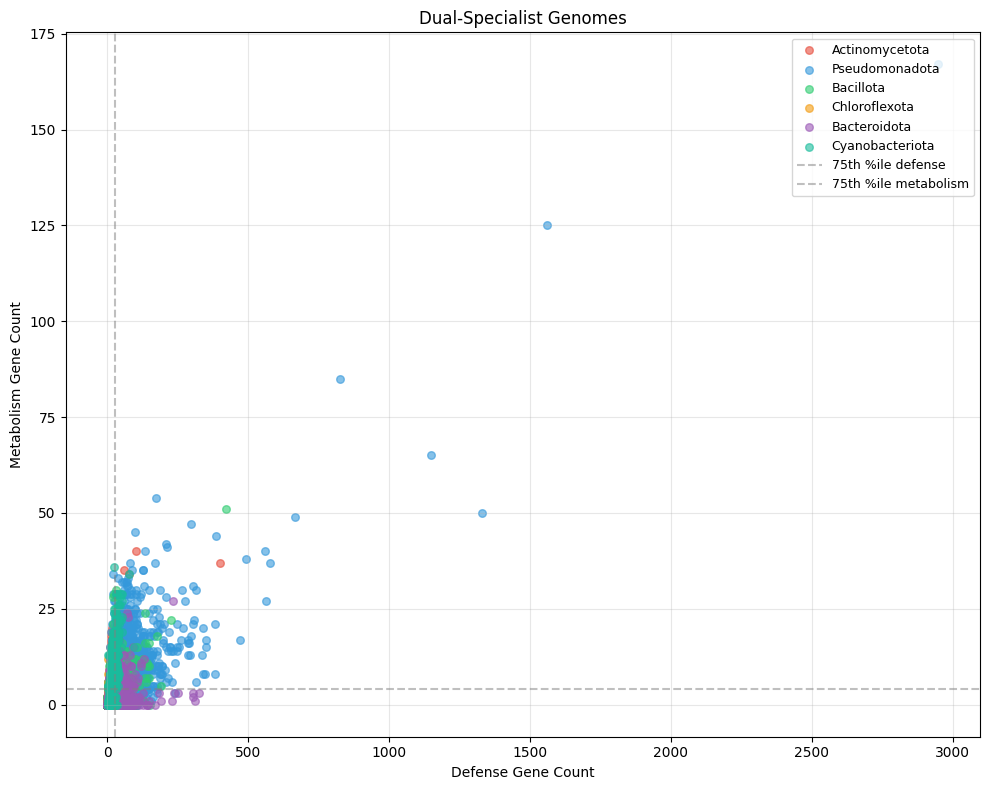

Dual specialists (both > 75th percentile): 3699
Total genomes: 27690
Figure saved: nb03_dual_specialist_scatter.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

phylum_colors = {
    'Actinomycetota': '#e74c3c',
    'Pseudomonadota': '#3498db',
    'Bacillota': '#2ecc71',
    'Chloroflexota': '#f39c12',
    'Bacteroidota': '#9b59b6',
    'Cyanobacteriota': '#1abc9c'
}

for phylum in MAJOR_PHYLA:
    phylum_data = genome_counts[genome_counts['phylum'] == phylum]
    ax.scatter(phylum_data['n_defense'], phylum_data['n_metabolism'],
              label=phylum, alpha=0.6, s=30,
              color=phylum_colors.get(phylum, '#95a5a6'))

# Mark 75th percentile thresholds
p75_def = genome_counts['n_defense'].quantile(0.75)
p75_met = genome_counts['n_metabolism'].quantile(0.75)

ax.axvline(x=p75_def, color='gray', linestyle='--', alpha=0.5, label=f'75th %ile defense')
ax.axhline(y=p75_met, color='gray', linestyle='--', alpha=0.5, label=f'75th %ile metabolism')

# Count dual specialists (both > 75th percentile)
dual_spec = ((genome_counts['n_defense'] > p75_def) & (genome_counts['n_metabolism'] > p75_met)).sum()

ax.set_xlabel('Defense Gene Count')
ax.set_ylabel('Metabolism Gene Count')
ax.set_title('Dual-Specialist Genomes')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "nb03_dual_specialist_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Dual specialists (both > 75th percentile): {dual_spec}")
print(f"Total genomes: {len(genome_counts)}")
print(f"Figure saved: nb03_dual_specialist_scatter.png")

In [9]:
# Broad co-occurrence breakdown (H3 — any-gene threshold, not 75th-pct)
n_total = len(genome_counts)
both_any     = ((genome_counts['n_defense'] > 0) & (genome_counts['n_metabolism'] > 0)).sum()
defense_only = ((genome_counts['n_defense'] > 0) & (genome_counts['n_metabolism'] == 0)).sum()
metab_only   = ((genome_counts['n_defense'] == 0) & (genome_counts['n_metabolism'] > 0)).sum()
neither      = ((genome_counts['n_defense'] == 0) & (genome_counts['n_metabolism'] == 0)).sum()

print("Broad co-occurrence (n_defense > 0 AND n_metabolism > 0):")
print(f"  Both classes:      {both_any:,}  ({both_any/n_total*100:.1f}%)")
print(f"  Defense only:      {defense_only:,}  ({defense_only/n_total*100:.1f}%)")
print(f"  Metabolism only:   {metab_only:,}  ({metab_only/n_total*100:.1f}%)")
print(f"  Neither:           {neither:,}  ({neither/n_total*100:.1f}%)")
print(f"  Sum check:         {both_any + defense_only + metab_only + neither:,} (should be {n_total:,})")

Broad co-occurrence (n_defense > 0 AND n_metabolism > 0):
  Both classes:      14,911  (53.8%)
  Defense only:      12,396  (44.8%)
  Metabolism only:   32  (0.1%)
  Neither:           351  (1.3%)
  Sum check:         27,690 (should be 27,690)
